# Reinforcement Learning from Human Feedback (RLHF)

## Part 1 — How Can a Machine Learn from Rewards?

Before understanding RLHF or how modern language models are trained,
we first need to understand a simpler question:

> **How can a machine learn what to do from rewards?**

In this notebook, we will build a tiny learning agent ourselves.
First, let's understand **Reinforcement Learning (RL)**.

## Imagine This...

You are standing in a room with **three doors**.

🚪 Door A  
🚪 Door B  
🚪 Door C

Behind one door is a reward.

You don't know which one.

Every time you choose a door, you receive some points.

Your objective:

> **Learn which door gives the highest reward.**

But there is one important rule...

Nobody tells you which door is best.

You have to **learn by trying**.

In [5]:
import random

doors = {
    "A": [0, 0, 1, 1, 2],
    "B": [0, 1, 2, 3, 4],
    "C": [2, 3, 4, 5, 6]
}

choice = input("Choose a door (A, B, or C): ").upper()

if choice in doors:
    reward = random.choice(doors[choice])
    print(f"\nYou chose Door {choice}")
    print(f"Reward received: {reward}")
else:
    print("Please choose A, B, or C.")

Choose a door (A, B, or C):  C



You chose Door C
Reward received: 6


## What Just Happened?

Every interaction had three important pieces:

### 1. Agent
The decision maker.

**You were the agent.**

### 2. Action
The decision made by the agent.

Choosing:

A, B, or C

was the **action**.

### 3. Reward
The feedback received after taking the action.

For example:

Door A → +1  
Door B → +3  
Door C → +5

The reward tells the agent:

> "How good was that action?"

## The Reinforcement Learning Loop

The basic idea is:
                        
                            Agent
                              ↓
                        Chooses an Action
                              ↓
                        Environment
                              ↓
                        Returns a Reward
                              ↓
                        Agent learns
                              ↓
                        Chooses again...

In [ ]:
                                  ACTION
                           ┌─────────────────►
                           │
                       ┌───┴───┐          ┌─────────────┐
                       │ AGENT │          │ ENVIRONMENT │
                       └───▲───┘          └──────┬──────┘
                           │                     │
                           ◄─────────────────────┘
                                  REWARD

In [ ]:
# Experiment 1 — Can the computer learn the best door?

In [7]:
import random

true_rewards = {
    "A": 1,
    "B": 3,
    "C": 5
}

estimated_rewards = {
    "A": 0,
    "B": 0,
    "C": 0
}

counts = {
    "A": 0,
    "B": 0,
    "C": 0
}

print("Initial knowledge of our agent:")
print(estimated_rewards)

Initial knowledge of our agent:
{'A': 0, 'B': 0, 'C': 0}


### The agent initially knows absolutely nothing.

In [8]:
def choose_action():
    return random.choice(["A", "B", "C"])


def get_reward(action):
    noise = random.uniform(-1, 1)
    return true_rewards[action] + noise

 
#     choose_action()
#           ↓
# Agent decides what to do

#     get_reward()
#           ↓
# Environment tells the agent how good it was
    

## How Does the Agent Learn?

Suppose the agent chooses Door C.

It expected:
            3 points
But actually received:
            5 points.

There is an **error**:
Error = Actual Reward − Expected Reward
So:

            Error = 5 − 3 = 2
The agent should increase its expectation for Door C.

We can update it using:
        New Estimate = Old Estimate + α × Error

where **α** is the learning rate.

In [10]:
# Making the agent learn
alpha = 0.1

history = []

for step in range(100):
    action = choose_action()
    reward = get_reward(action)
    error = reward - estimated_rewards[action]
    estimated_rewards[action] += alpha * error
    counts[action] += 1
    history.append(
        (step, action, reward, estimated_rewards[action])
    )
print("Learned estimates:\n")

for door, value in estimated_rewards.items():
    print(f"Door {door}: {value:.2f}")

Learned estimates:

Door A: 0.94
Door B: 2.91
Door C: 5.15


### "Nobody told the agent that C was the best door. So how did it discover it?" THROUGH REWARDS!

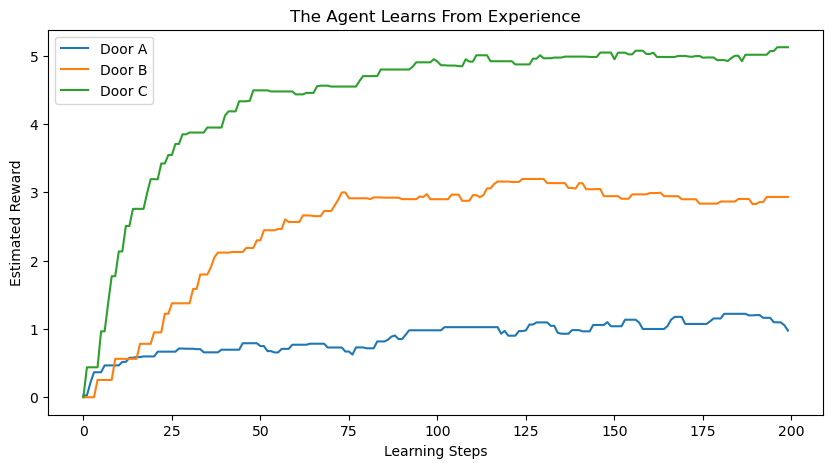

In [11]:
# Visualization

import matplotlib.pyplot as plt

steps = []
values_A = []
values_B = []
values_C = []

estimated = {"A": 0, "B": 0, "C": 0}

for step in range(200):

    action = random.choice(["A", "B", "C"])

    reward = get_reward(action)

    error = reward - estimated[action]

    estimated[action] += 0.1 * error

    steps.append(step)

    values_A.append(estimated["A"])
    values_B.append(estimated["B"])
    values_C.append(estimated["C"])


plt.figure(figsize=(10, 5))

plt.plot(steps, values_A, label="Door A")
plt.plot(steps, values_B, label="Door B")
plt.plot(steps, values_C, label="Door C")

plt.xlabel("Learning Steps")
plt.ylabel("Estimated Reward")
plt.title("The Agent Learns From Experience")
plt.legend()

plt.show()

In [ ]:
At the beginning:
A ≈ B ≈ C

Eventually:
C > B > A

# What Is a Policy?

In Reinforcement Learning, the agent needs a strategy for choosing actions.

That strategy is called a:

## POLICY

A policy answers:

> "Given the current situation, what action should I take?"

For our door example:

Policy:

Door A → 10%  
Door B → 20%  
Door C → 70%

The policy does not necessarily say:

"Always choose C."

Instead, it can describe the **probability of choosing each action**.

#### A policy is simply the agent's behaviour or decision-making strategy.

In [13]:
# A Policy in Python

policy = {
    "A": 0.10,
    "B": 0.20,
    "C": 0.70
}

print("Agent's Policy\n")

for action, probability in policy.items():
    print(f"P({action}) = {probability:.0%}")

Agent's Policy

P(A) = 10%
P(B) = 20%
P(C) = 70%


# Four Ideas to Remember

Before moving forward, remember these four concepts.

| Concept | Meaning |
|---|---|
| **Agent** | The thing making decisions |
| **Action** | What the agent chooses |
| **Reward** | Feedback about how good the action was |
| **Policy** | The strategy used to choose actions |

The learning objective is:

> **Change the policy so that actions producing higher rewards become more likely.**

# Lets see whether you have got it !

Imagine an agent has this policy:

A → 33%  
B → 33%  
C → 34%

After interacting with the environment many times, it discovers:

A usually gives → 1 point  
B usually gives → 5 points  
C usually gives → 2 points

### Discuss with your group

1. Which action should become more likely?
2. Which actions should become less likely?
3. What should happen to the policy?
4. What information allowed the agent to learn?

In [ ]:
# B should increase.
# A and C should decrease.
# The policy should shift toward B.
# The reward signal allowed the agent to learn.

# But There Is a Problem...

Our environment had a very convenient property.

We knew how to calculate the reward.

Door A → reward  
Door B → reward  
Door C → reward

But what if the task were:

> "Write a helpful answer."

How would we calculate the reward?

## Consider these two responses

### User
> Explain photosynthesis to an 8-year-old.

### Response A

Photosynthesis is a biochemical process involving
photochemical reactions and carbon fixation pathways
within chloroplasts.

### Response B

Plants are a little like tiny solar-powered kitchens! .................

They use sunlight, water, and air to make their own food.
While doing this, they also release oxygen into the air.

---

### Question

Which response is better for this user?

And more importantly...

## How could a computer calculate the reward?

# Traditional RL

### Agent → Action → Environment → Reward

# Language Model

### LLM → Response → ????? → Reward


# RL + HF = RLHF